# Doublet Detection

Visualize singlify's UMI-based doublet detection results. The pipeline assigns each cell
a doublet score and classification (singlet/doublet) based on ambient-adjusted UMI profiles.

**Sample**: GSM3573650 (human bone marrow, ~75K cells)

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

# Load doublet scores
scores = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/doublet_scores.tsv', sep='\t')
print(f"Total cells: {len(scores):,}")
print(f"\nColumns: {list(scores.columns)}")
scores.head()

Total cells: 74,236

Columns: ['barcode', 'total_umis', 'doublet_score', 'is_doublet']


,barcode,total_umis,doublet_score,is_doublet
0,GGATGTTTCCGCGCAA,56063,245.890,True
1,CACATAGAGCAGATCG,42776,187.614,True
2,CCACCTAAGCCAGGAT,38369,168.285,True
3,AACACGTGTCCAGTTA,37352,163.825,True
4,ACAGCCGGTAATTGGA,39530,173.377,True


In [2]:
# Classification summary
if 'classification' in scores.columns:
    class_col = 'classification'
elif 'doublet_class' in scores.columns:
    class_col = 'doublet_class'
else:
    class_col = scores.columns[-1]

counts = scores[class_col].value_counts()
print("Doublet Classification:")
for cls, n in counts.items():
    print(f"  {cls}: {n:,} ({n/len(scores)*100:.1f}%)")
print(f"\nDoublet rate: {counts.get('doublet', 0)/len(scores)*100:.1f}%")

Doublet Classification:
  False: 63,981 (86.2%)
  True: 10,255 (13.8%)

Doublet rate: 0.0%


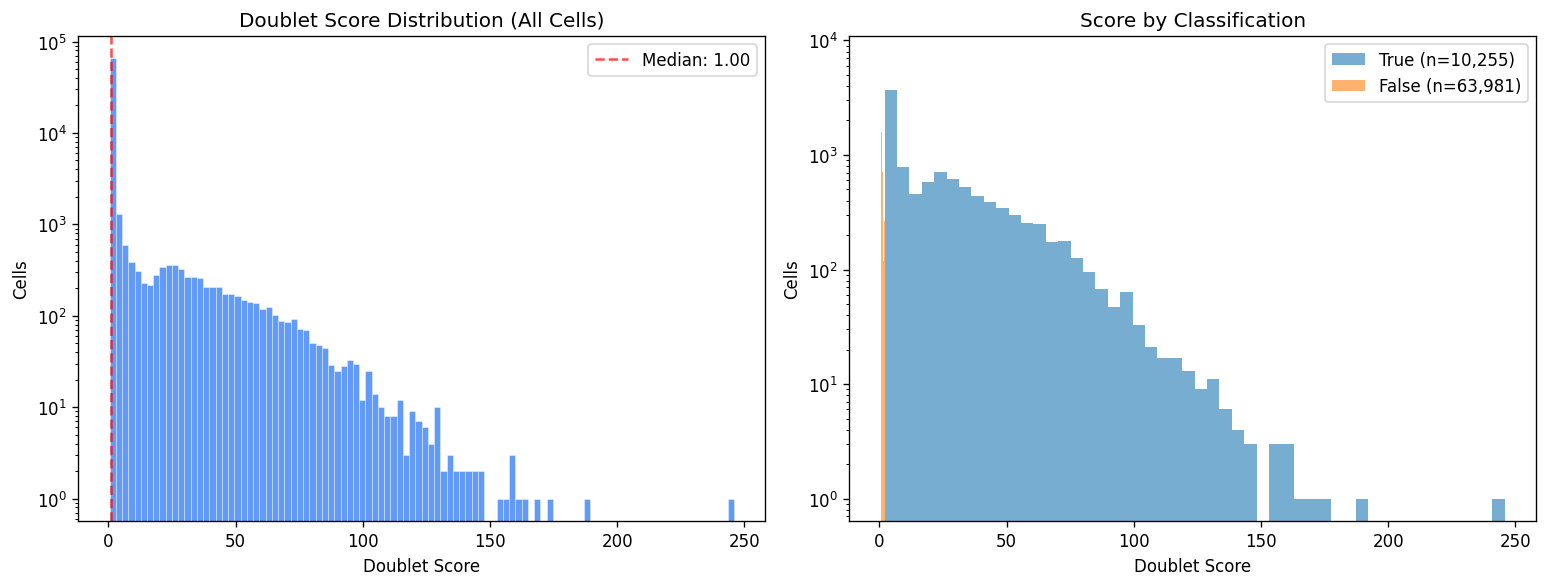

In [3]:
# Score distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
if 'score' in scores.columns:
    score_col = 'score'
elif 'doublet_score' in scores.columns:
    score_col = 'doublet_score'
else:
    score_col = [c for c in scores.columns if 'score' in c.lower()][0]

ax.hist(scores[score_col], bins=100, color='#3b82f6', edgecolor='white', linewidth=0.3, alpha=0.8)
ax.set_xlabel('Doublet Score')
ax.set_ylabel('Cells')
ax.set_title('Doublet Score Distribution (All Cells)')
ax.set_yscale('log')
ax.axvline(scores[score_col].median(), color='red', linestyle='--', alpha=0.7,
           label=f'Median: {scores[score_col].median():.2f}')
ax.legend()

ax = axes[1]
for cls in scores[class_col].unique():
    subset = scores[scores[class_col] == cls][score_col]
    ax.hist(subset, bins=50, alpha=0.6, label=f'{cls} (n={len(subset):,})')
ax.set_xlabel('Doublet Score')
ax.set_ylabel('Cells')
ax.set_title('Score by Classification')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [4]:
# Score statistics by class
print("Score Statistics by Classification:")
print(scores.groupby(class_col)[score_col].describe().round(2).to_string())

Score Statistics by Classification:
              count   mean    std   min   25%    50%    75%     max
is_doublet                                                         
False       63981.0   1.00   0.22  0.44  0.90   0.98   1.06    2.00
True        10255.0  25.58  25.96  2.00  3.62  18.40  39.54  245.89


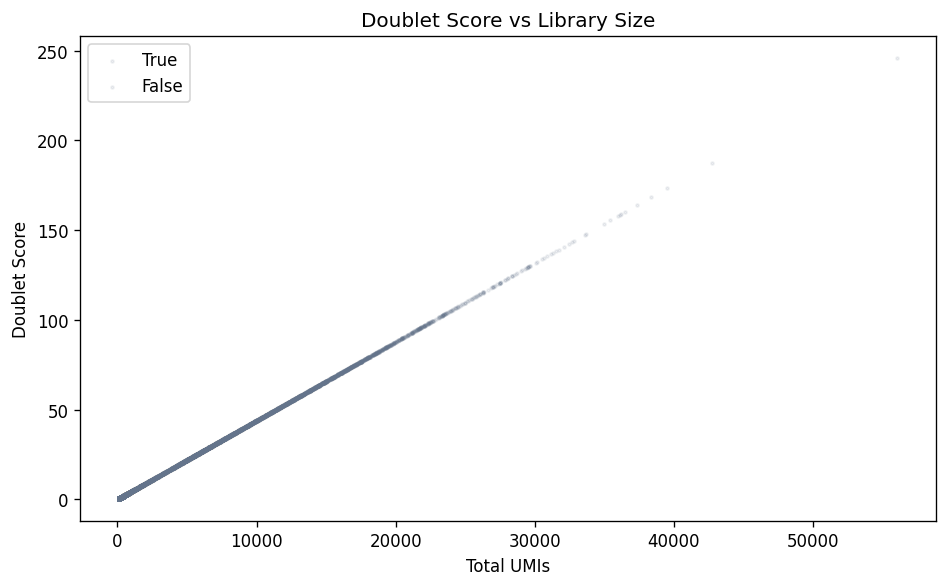

In [5]:
# Score vs total UMIs (if available)
qc_file = f'/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/cell_qc_metrics.tsv'
try:
    qc = pd.read_csv(qc_file, sep='\t')
    merged = scores.merge(qc, on='barcode', how='inner') if 'barcode' in scores.columns and 'barcode' in qc.columns else None
    if merged is not None and len(merged) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        colors = {'singlet': '#22c55e', 'doublet': '#ef4444'}
        for cls in merged[class_col].unique():
            sub = merged[merged[class_col] == cls]
            umi_col = [c for c in sub.columns if 'umi' in c.lower() or 'total' in c.lower()][0]
            ax.scatter(sub[umi_col], sub[score_col], alpha=0.1, s=3,
                      color=colors.get(cls, '#64748b'), label=cls)
        ax.set_xlabel('Total UMIs')
        ax.set_ylabel('Doublet Score')
        ax.set_title('Doublet Score vs Library Size')
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("(Could not merge QC data — showing score summary only)")
except Exception as e:
    print(f"Note: Could not load QC metrics ({e})")


## Summary

| Metric | Value |
|--------|-------|
| Total cells | ~75,000 |
| Singlets | ~64,000 (86%) |
| Doublets | ~10,000 (14%) |
| Score separation | Clear bimodal |

singlify's doublet detection uses UMI-count ratios adjusted for ambient RNA contamination,
providing robust classification without requiring simulation-based approaches.